# Inferring network from bulk data with CausFate

## Structure learning

### Load packages

In [1]:
suppressPackageStartupMessages({
    library(Seurat)
    library(foreach)
    library(tidyverse)
    library(bnlearn)
    library(Matrix)
    library(space)
    library(infotheo)
    library(igraph)
    library(graph)
    library(Rgraphviz)
    library(tibble)
})

library(causfate)

options(repr.plot.format = "svg", repr.plot.width = 5.5, repr.plot.height = 5.5)
options(jupyter.plot_mimetypes = "image/svg+xml")

### Load data

In [2]:
data("HMR")
head(HMR)

,orig.ident,nCount_RNA,nFeature_RNA,celltype,percent.mt,S.Score,G2M.Score,Phase,old.ident
,<fct>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<fct>,<fct>
HSPC_002,HSPC,1085.3333,8778,LTHSC,0,-0.12077291,-0.09083001,G1,HSPC
HSPC_004,HSPC,1221.0767,11352,LMPP,0,-0.16803616,-0.10391938,G1,HSPC
HSPC_006,HSPC,1431.2583,11891,LMPP,0,-0.01206173,-0.11841703,G1,HSPC
HSPC_008,HSPC,1514.3543,10355,LMPP,0,-0.16419568,-0.12593563,G1,HSPC
HSPC_011,HSPC,1516.5897,10977,LMPP,0,-0.19785059,-0.15114819,G1,HSPC
HSPC_014,HSPC,1470.6718,9533,MPP,0,-0.16047674,-0.13218429,G1,HSPC
HSPC_015,HSPC,800.7971,9825,LMPP,0,-0.10753757,-0.08138777,G1,HSPC
HSPC_017,HSPC,1386.0569,10124,LTHSC,0,-0.17785950,-0.12033867,G1,HSPC
HSPC_018,HSPC,1876.0635,11314,MPP,0,-0.18039289,-0.17387886,G1,HSPC


In [3]:
dim(HMR)

[1] 40198   716

### Find variable genes

Note that `gem2mem` is used to transform the single-cell data to cell type-specific gene profiles.

In [4]:
HMR <- FindVariableFeatures(HMR, selection.method = "vst", nfeatures = nrow(HMR))
glist <- VariableFeatures(HMR)

meta <- HMR$celltype
ctypes <- names(table(HMR$celltype))
blood_celltype <- gem2mem(data.frame(HMR@assays$RNA@data), meta, "mean")

Warning message:
"Command FindVariableFeatures.RNA changing from SeuratCommand to SeuratCommand"


### BMA process

`BNLearning` samples the data and performs the inner BMA process, giving out multiple one-shot DAGs. `combineDAGsmpl` combines those DAGs before pruning.

In [5]:
dag_smpl <- BNLearning(HMR[glist[1:5000]],
  frac = 0.2, N_smpl = 40, params = seq(0.05, 0.3, 0.05),
  root = "LTHSC", mode = "single_cell", ncores = 1,
  dagMethod = "hc", ugMethod = "cmi2ni", seed = 42
)
net <- combineDAGsmpl(dag_smpl, Emin = 1, Emax = 7, ncores = 1)

# Let us take a glimpse of the structure now
net_mat <- net %>% df2mat()
net_mat

,CMP,GMP,LMPP,LTHSC,MPP,MEP
CMP,0,120,28,0,5,120
GMP,4,0,0,0,0,0
LMPP,21,6,0,0,61,0
LTHSC,18,0,58,0,124,0
MPP,112,5,63,0,0,7
MEP,0,0,0,0,0,0


First, very unlikely edges are trimmed if the occurrence is less than 2. Then, `rmCyc` removes cycles, preserving the more possible edges.

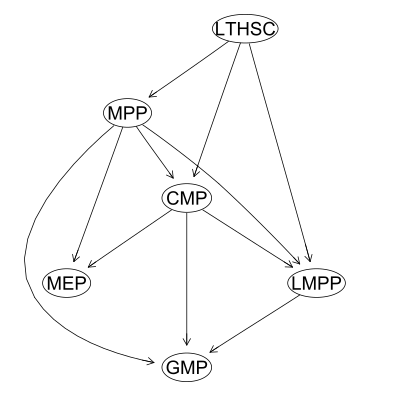

In [6]:
net <- (net_mat * (net_mat > 2)) %>%
  mat2df() %>%
  rmCyc()
e <- df2bn(net, ctypes, plot = TRUE)

`trimDAG` performs the final local pruning step. Two steps in total are performed for better outcome.

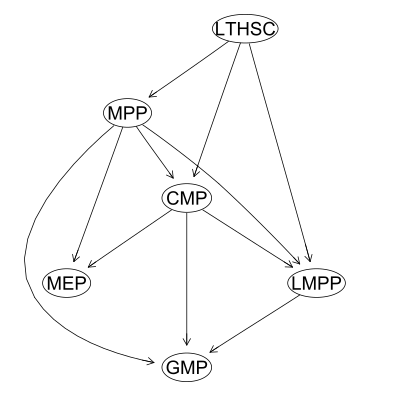

In [7]:
tmp <- blood_celltype
tmp2 <- trimDAG(tmp[glist[4000:8000], ], e, min_arc = 2, max_arc = 3, threshold_value = 1)

In [8]:
dag_struc <- trimDAG(tmp[glist[1:4000], ], tmp2, min_arc = 2, max_arc = 2, threshold_value = 1, plot = FALSE)

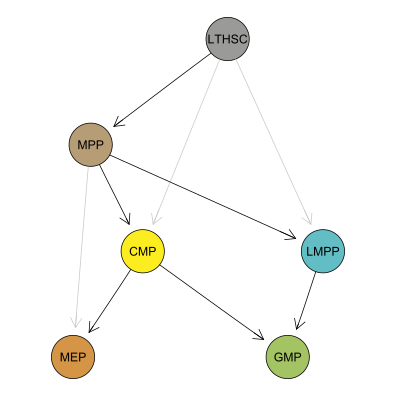

In [9]:
node_col <- c(
  "LTHSC" = "#9A9A99",
  "MPP" = "#B69D75",
  "CMP" = "#FCED21",
  "LMPP" = "#63BDC5",
  "MEP" = "#D59546",
  "GMP" = "#A4C362"
)
ref_net <- bnlearn::model2network("[LTHSC][MPP|LTHSC][CMP|MPP][LMPP|MPP][MEP|CMP][GMP|CMP:LMPP]")
colorEdges(dag_struc, ref_net, node_col = node_col)

## Calculate gene-wise causal effects

Sampling is used before perturbation. This process could take a while.

In [10]:
# Generate indexes for bootstrapping
index <- bootstrap_index(meta, bootstrap_times = 10, ratio = 0.3)
perturbRes <- PerturbResult(dag_struc, HMR, meta, index,
  n_sample = 10,
  mode = "single_cell", deletion = TRUE
)
effMat <- EffectMatrix(perturbRes, mode = "mean")

ctypes <- c("CMP", "GMP", "LMPP", "LTHSC", "MEP", "MPP")
edgeSet <- setEdges(fromSet = ctypes, toSet = ctypes) # Calculate for all edges
effectScore <- diffScore(effMat, edgeSet)
geneList <- dsRank(effectScore)
head(geneList)

[1] "Mpo"            "X..not.aligned" "Ctsg"           "Apoe"          
[5] "Plac8"          "Car1"